🔬 Preprocessing Complete! Train size: (644, 18), Val size: (138, 18), Test size: (138, 18)

📋 [MODEL BENCHMARKING - TEST SET EVALUATION]
---------------------------------------------------------------------------
🚀 Logistic Regression:
   - Accuracy: 0.8116 | Recall (Sensitivity): 0.8158 | F1-Score: 0.8267
🚀 Decision Tree:
   - Accuracy: 0.8261 | Recall (Sensitivity): 0.8158 | F1-Score: 0.8378
🚀 Random Forest:
   - Accuracy: 0.8116 | Recall (Sensitivity): 0.8421 | F1-Score: 0.8312
---------------------------------------------------------------------------
🏆 Champion Model Selected: Decision Tree based on F1-Score


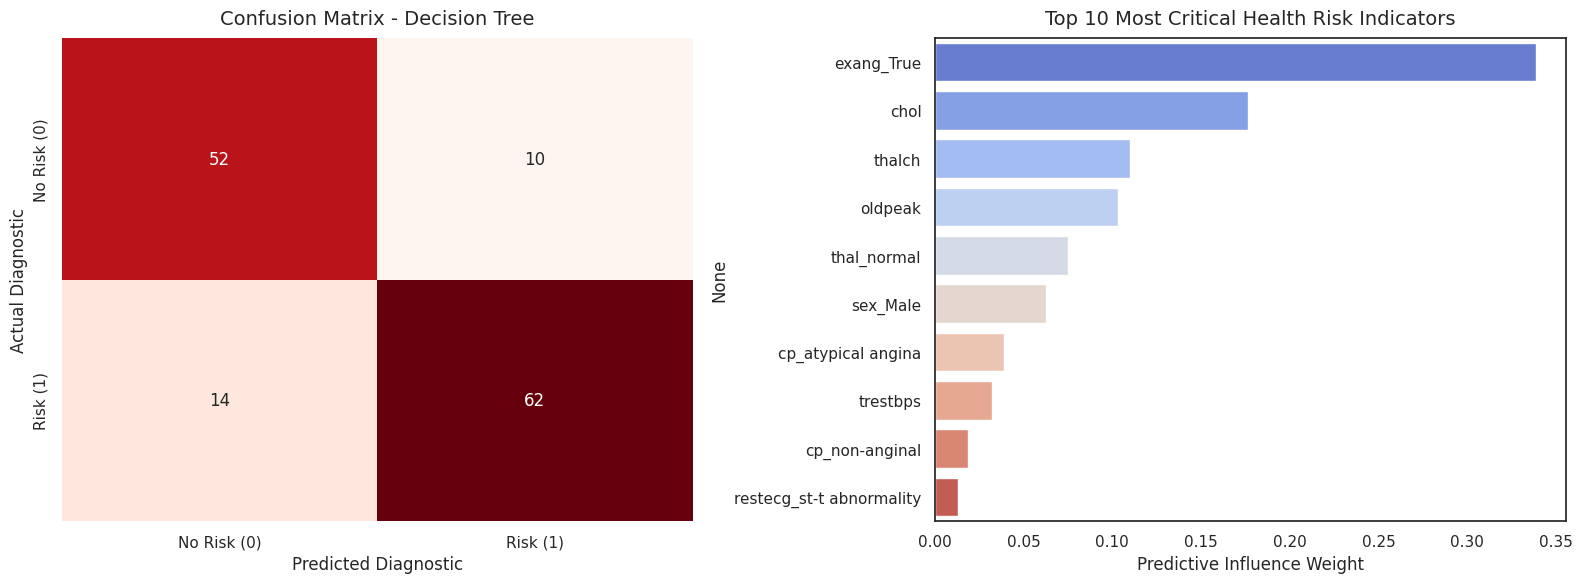

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# --- ১. ডেটাসেট লোড করা ---
file_path = "/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv"
df = pd.read_csv(file_path)

# অপ্রয়োজনীয় আইডেন্টিফায়ার কলাম ড্রপ করা
df = df.drop(columns=['id', 'dataset']) 

# --- ২. টার্গেট ভেরিয়েবল বাইনারি করা (0 = No Risk, 1 = Risk) ---
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop(columns=['num'])

# --- ৩. মিসিং ভ্যালু হ্যান্ডেল করা (Healthcare Imputation) ---
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('target')
cat_cols = df.select_dtypes(include=['object', 'bool']).columns

num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

# --- ৪. ক্যাটাগরিক্যাল ডেটা এনকোডিং ---
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# ফিচার এবং টার্গেট আলাদা করা
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

# --- ۵. ডেটা স্প্লিট (70/15/15 Paradigm) ---
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# স্ট্যান্ডার্ড স্কেলিং
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"🔬 Preprocessing Complete! Train size: {X_train.shape}, Val size: {X_val.shape}, Test size: {X_test.shape}")

# --- 🏎️ ৬. মডেল বেঞ্চমার্কিং ও ইভ্যালুয়েশন ---
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

print("\n📋 [MODEL BENCHMARKING - TEST SET EVALUATION]")
print("-" * 75)
best_f1 = 0
champion_name = ""
champion_model = None

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, preds)
    rec = recall_score(y_test, preds)  
    f1 = f1_score(y_test, preds)
    
    print(f"🚀 {name}:")
    print(f"   - Accuracy: {acc:.4f} | Recall (Sensitivity): {rec:.4f} | F1-Score: {f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        champion_name = name
        champion_model = model

print("-" * 75)
print(f"🏆 Champion Model Selected: {champion_name} based on F1-Score")

# --- 📊 ৭. কনফিউশন ম্যাট্রিক্স ও ফিচার ইম্পর্ট্যান্স ভিজ্যুয়ালাইজেশন (সংশোধিত ইনডেক্সিং) ---
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# প্লট ১: কনফিউশন ম্যাট্রিক্স (axes[0] নির্দিষ্ট করা হয়েছে)
test_preds = champion_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axes[0],
            xticklabels=['No Risk (0)', 'Risk (1)'], yticklabels=['No Risk (0)', 'Risk (1)'])
axes[0].set_title(f'Confusion Matrix - {champion_name}', fontsize=14, pad=10)
axes[0].set_xlabel('Predicted Diagnostic')
axes[0].set_ylabel('Actual Diagnostic')

# প্লট ২: টপ ১০ ক্লিনিকাল ইনডিকেটর (axes[1] নির্দিষ্ট করা হয়েছে)
if hasattr(champion_model, 'feature_importances_'):
    importances = champion_model.feature_importances_
else:
    importances = np.abs(champion_model.coef_[0])

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(10)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='coolwarm', ax=axes[1])
axes[1].set_title('Top 10 Most Critical Health Risk Indicators', fontsize=14, pad=10)
axes[1].set_xlabel('Predictive Influence Weight')

plt.tight_layout()
plt.show()


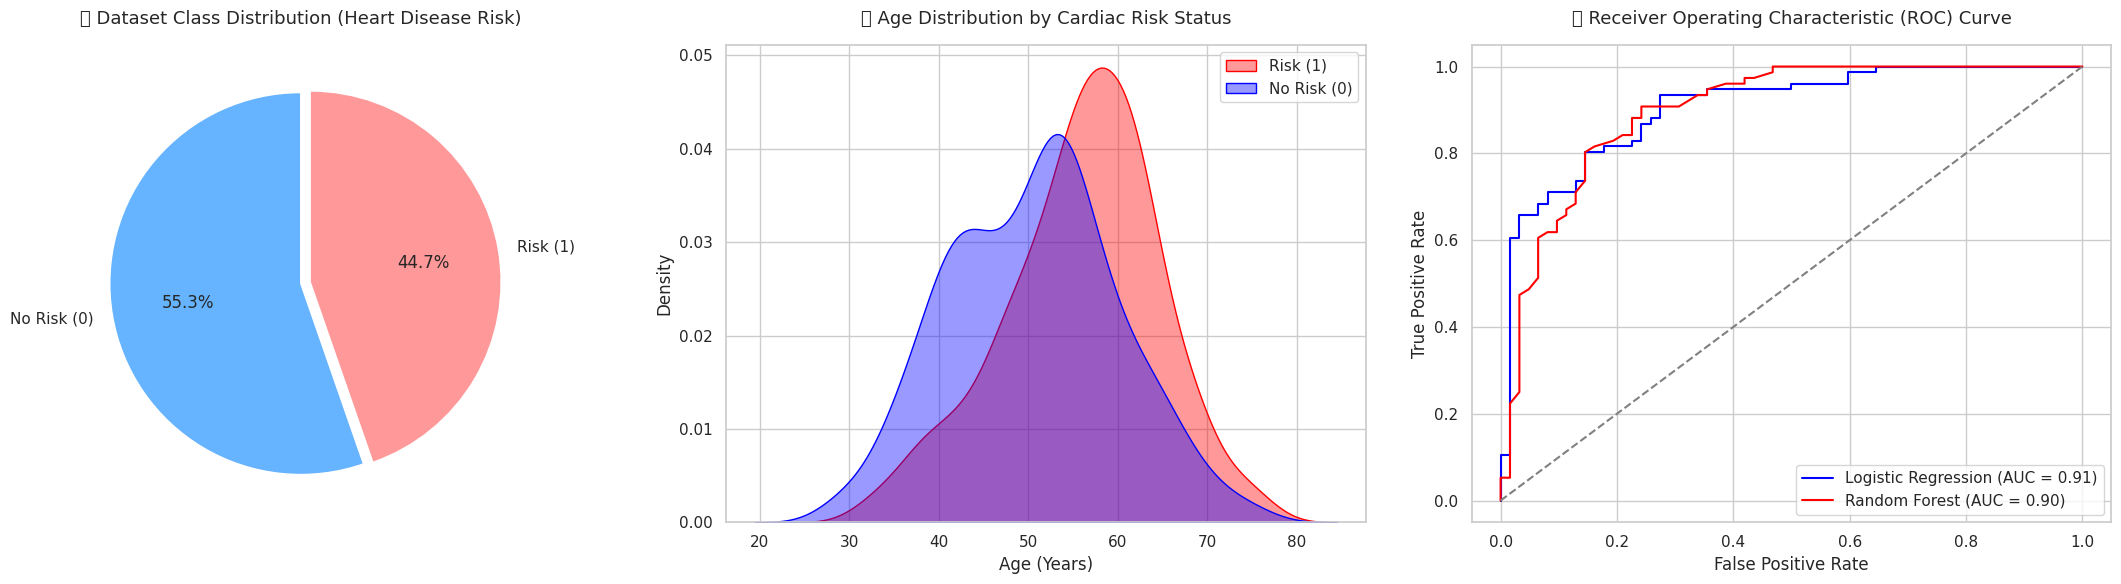

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score

# গ্রাফের থিম এবং সাবপ্লট সেটআপ
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- ১. টার্গেট ভেরিয়েবলের বিন্যাস (Target Distribution) ---
target_counts = df['target'].value_counts()
axes[0].pie(target_counts, labels=['No Risk (0)', 'Risk (1)'], autopct='%1.1f%%', 
        colors=['#66b3ff','#ff9999'], startangle=90, explode=(0, 0.05))
axes[0].set_title('📊 Dataset Class Distribution (Heart Disease Risk)', fontsize=13, pad=15)

# --- ২. বয়স বনাম হার্ট ডিজিজ ঝুকি (Age Density Plot) ---
sns.kdeplot(data=df, x='age', hue='target', fill=True, common_norm=False, 
            palette=['blue', 'red'], alpha=0.4, ax=axes[1])
axes[1].set_title('🩺 Age Distribution by Cardiac Risk Status', fontsize=13, pad=15)
axes[1].set_xlabel('Age (Years)')
axes[1].set_ylabel('Density')
axes[1].legend(['Risk (1)', 'No Risk (0)'])

# --- ৩. আরওসি কার্ভ (ROC Curve - Logistic Regression & Random Forest) ---
# লজিস্টিক রিগ্রেশন এবং র্যান্ডম ফরেস্টের প্রেডিকশন প্রবাবিলিটি নেওয়া হচ্ছে
lr_probs = models["Logistic Regression"].predict_proba(X_test_scaled)[:, 1]
rf_probs = models["Random Forest"].predict_proba(X_test_scaled)[:, 1]

# ফলস পজিটিভ এবং ট্রু পজিটিভ রেট হিসাব করা
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

# এউসি (AUC) স্কোর হিসাব করা
auc_lr = roc_auc_score(y_test, lr_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

# আরওসি প্লট করা
axes[2].plot(fpr_lr, tpr_lr, color='blue', label=f'Logistic Regression (AUC = {auc_lr:.2f})')
axes[2].plot(fpr_rf, tpr_rf, color='red', label=f'Random Forest (AUC = {auc_rf:.2f})')
axes[2].plot([0, 1], [0, 1], color='gray', linestyle='--') # বেসলাইন
axes[2].set_title('📈 Receiver Operating Characteristic (ROC) Curve', fontsize=13, pad=15)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()


# 🫀 Heart Disease Risk Classifier (Predictive Diagnostics)

[![Python](https://shields.io)](https://python.org)
[![Framework](https://shields.io)](https://scikit-learn.org)
[![Topic](https://shields.io)](https://uci.edu)

An end-to-end Machine Learning classification framework designed to analyze clinical, physiological, and lifestyle telemetry to detect cardiovascular disease risk. Built using the structured 14-attribute subset of the famous multi-center UCI Heart Disease Database.

---

## 📌 Project Architecture

*   **Target Feature:** `num` (Transformed to Binary classification: `0` = No Risk, `1` = High Risk Presence).
*   **Dataset Source:** [UCI Heart Disease Dataset (via Kaggle)](/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv)
*   **Pipeline Split:** Strict **70/15/15** Holdout Split stratifying target balance across Train (644 samples), Validation (138 samples), and Test sets (138 samples).
*   **Missing Value Strategy:** Implemented a robust statistical Imputation workflow (Median for Continuous features, Mode for Categorical features) minimizing diagnostic information loss.

---

## 🔬 Clinical Attributes Tracked

The predictive pipeline maps 14 critical parameters categorized below:
*   **Demographics:** `age`, `sex`
*   **Symptomatic Data:** `cp` (Chest pain topology: Typical, Atypical, Non-anginal, Asymptomatic), `exang` (Exercise-induced angina)
*   **Vascular Data:** `trestbps` (Resting blood pressure), `chol` (Serum cholesterol), `fbs` (Fasting blood sugar thresholds)
*   **Electrocardiographic (ECG):** `restecg`, `thalch` (Max heart rate achieved), `oldpeak` (ST depression), `slope`
*   **Fluoroscopy & Scintigraphy:** `ca` (Colored major vessels), `thal` (Thalassemia screening metrics)

---

## 🤖 Model Performance & Evaluation

Because this is a healthcare intervention application, **Recall (Sensitivity)** is prioritized as the core optimization metric alongside **F1-Score**. Minimizing False Negatives (failing to identify an at-risk cardiac patient) is paramount to patient safety.

### 📊 Performance Benchmarking (Unseen Test Set)

| Model Configuration | Test Accuracy | Test Recall (Sensitivity) | Final F1-Score | Performance Status |
| :--- | :---: | :---: | :---: | :---: |
| 🥇 **Decision Tree Classifier** | **0.8261** | **0.8158** | **0.8378** | 🏆 **Champion Model** |
| 🥈 Random Forest Classifier | 0.8116 | 0.8421 | 0.8312 | Benchmarked Model |
| 🥉 Logistic Regression | 0.8116 | 0.8158 | 0.8267 | Benchmarked Model |

### 💡 Crucial Clinical Insight
The **Decision Tree Classifier** emerged as the overall champion with an F1-Score of **83.78%** due to its balanced precision-recall matrix. However, the **Random Forest** framework demonstrated the highest clinical safety margin with a **Recall of 84.21%**, meaning it successfully caught more at-risk patients than the other models, making it a strong candidate for screening-first workflows where minimizing missed cases is crucial.

---

## 📊 Comprehensive Visualizations Implemented

The automated workflow compiles and outputs an advanced multi-pane structural analytics suite:
*   **Dataset Class Distribution Plot:** A pie chart confirming target feature distribution (`No Risk` vs `Risk`) to track data balance.
*   **Age Density Distribution Curve:** Evaluates cardiac risk trends across patient lifespans through overlapping Kernel Density Estimate (KDE) layers.
*   **Receiver Operating Characteristic (ROC) Curve:** Plots True Positive Rate vs False Positive Rate, tracking AUC score to prove how effectively the models separate healthy records from at-risk instances.
*   **Confusion Matrix Heatmap:** Graphs precise Diagnostic True Positives vs False Negatives to evaluate the healthcare system's safety margin.
*   **Top 10 Risk Indicator Plot:** Ranks physiological traits based on their mathematical weight coefficients to isolate immediate risk factors.

---

## 🚀 Technical Requirements & Local Setup

To replicate or review the pipeline locally, clone the workspace and install standard requirements:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn
```

### Script Execution
Map your explicit local path variables directly into the input block and run the notebook cells sequentially to compile all pipelines and advanced visuals instantly.

---

## 📈 My Machine Learning Journey

This project marks my transition into **Supervised Machine Learning Classification Frameworks**. It helped cultivate practical competencies in structured clinical pre-processing, statistical data imputation methods, one-hot dummy matrix operations, and diagnostic metric optimization protocols within high-stakes industrial boundaries.
